# 🔹 Task 1 –
Data Understanding
Load dataset using ImageDataGenerator
Print:
Number of training images
Number of validation images
Display 5 sample X-ray images


In [34]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\peesa\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [35]:
train_dir = path + '/chest_xray/train'
val_dir = path + '/chest_xray/val'

In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [38]:
keras_train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

Found 5216 images belonging to 2 classes.


In [39]:
keras_validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale'
)

Found 16 images belonging to 2 classes.


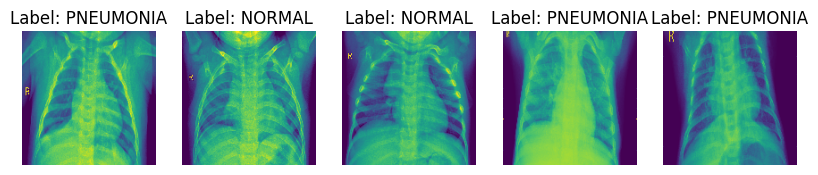

In [ ]:
images, labels = next(keras_train_generator)

plt.figure(figsize=(10,6))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title("Label: " + ("PNEUMONIA" if labels[i]==1 else "NORMAL"))
    plt.axis("off")

plt.show()

In [45]:
import matplotlib.pyplot as plt

In [50]:
print("Number of training images:", keras_train_generator.samples)
print("Number of validation images:", keras_validation_generator.samples)



Number of training images: 5216
Number of validation images: 16


# Task 2 –
Build CNN Architecture
Students must design this architecture:
Input (150x150x1)
↓
Conv2D (32 filters, 3x3) + ReLU
↓
MaxPooling (2x2)
↓
Conv2D (64 filters, 3x3) + ReLU
↓
MaxPooling (2x2)
↓
Conv2D (128 filters, 3x3) + ReLU
↓
MaxPooling (2x2)
↓
Flatten
↓
Dense (128) + ReLU
↓
Dropout (0.5)
↓
Dense (1) + Sigmoid

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

c:\Users\peesa\OneDrive\Desktop\vignan\3-1\COE\mnist\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,827,905 (18.42 MB)

 Trainable params: 4,827,905 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

# Task 3 –
Training Setup
Loss: Binary Crossentropy
Optimizer: Adam
Metric: Accuracy
Epochs: 15

In [54]:
#Compile the model
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    keras_train_generator,
    epochs=5,
    validation_data=keras_validation_generator
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.8988 - loss: 0.2501 - val_accuracy: 0.8125 - val_loss: 0.3935
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 720ms/step - accuracy: 0.9571 - loss: 0.1221 - val_accuracy: 0.8750 - val_loss: 0.3063
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 808ms/step - accuracy: 0.9594 - loss: 0.1052 - val_accuracy: 0.7500 - val_loss: 0.6446
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 657ms/step - accuracy: 0.9645 - loss: 0.1003 - val_accuracy: 0.9375 - val_loss: 0.1939
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 388ms/step - accuracy: 0.9745 - loss: 0.0761 - val_accuracy: 0.8750 - val_loss: 0.2364


In [57]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Reset the validation generator to ensure predictions are made on the full dataset in order
keras_validation_generator.reset()

# Get true labels
y_true = keras_validation_generator.classes

# Get predictions
y_pred_prob = model.predict(keras_validation_generator)

# Convert probabilities to binary predictions (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)

# Print Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
Confusion Matrix:
[[2 6]
 [4 4]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.33      0.25      0.29         8
   PNEUMONIA       0.40      0.50      0.44         8

    accuracy                           0.38        16
   macro avg       0.37      0.38      0.37        16
weighted avg       0.37      0.38      0.37        16




Sample Predictions:


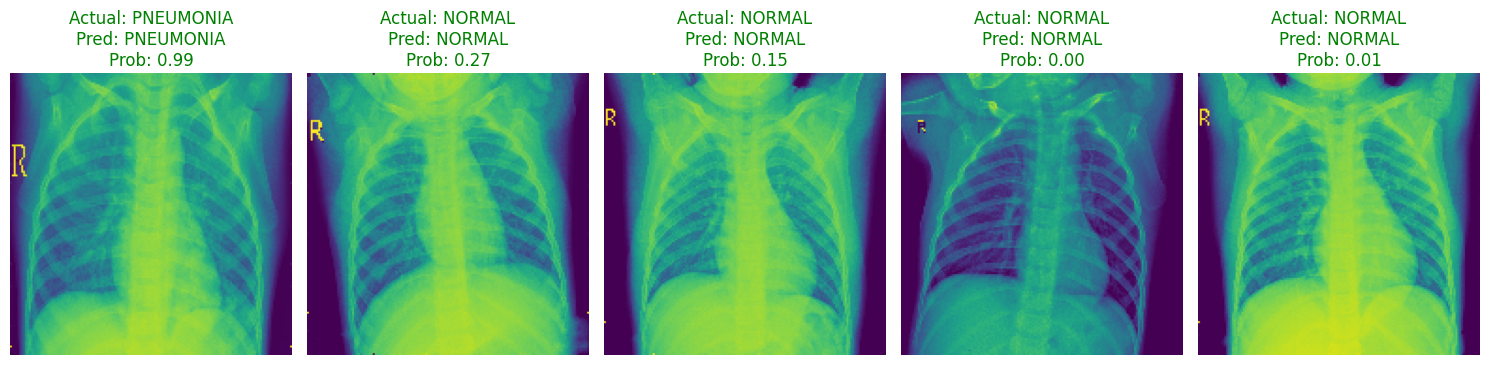

In [59]:
import matplotlib.pyplot as plt

# Display 5 sample predictions
print("\nSample Predictions:")

# Get some samples from the validation generator
keras_validation_generator.reset() # Reset again for fresh samples
images_sample, labels_sample = next(keras_validation_generator)

class_names = {0: 'NORMAL', 1: 'PNEUMONIA'}

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images_sample[i].reshape(150, 150))
    plt.axis('off')

    # Make prediction for this image
    img_batch = np.expand_dims(images_sample[i], axis=0)
    prediction_prob = model.predict(img_batch, verbose=0)[0][0]
    predicted_class = 1 if prediction_prob > 0.5 else 0

    actual_label = class_names[labels_sample[i]]
    predicted_label = class_names[predicted_class]

    color = "green" if actual_label == predicted_label else "red"
    plt.title(f"Actual: {actual_label}\nPred: {predicted_label}\nProb: {prediction_prob:.2f}", color=color)

plt.tight_layout()
plt.show()

In [60]:
model.save("model.h5")
print("Model saved successfully!")

Model saved successfully!
